# 01 — Sintetik Data (Faqat ish kunlari)

**O'zgarishlar:**
- Faqat ish kunlari (Du-Ju, `freq='B'`)
- Bayramlar va dam olish kunlari **olib tashlanadi**
- Weekly pattern olib tashlandi
- Bayram oldi effekti saqlanadi

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [9]:
UZBEK_HOLIDAYS = {
    '2024-01-01': 'Yangi yil', '2024-03-08': 'Xotin-qizlar kuni',
    '2024-03-21': "Navro'z", '2024-04-10': 'Ramazon hayit',
    '2024-05-09': 'Xotira kuni', '2024-06-17': 'Qurbon hayit',
    '2024-09-01': 'Mustaqillik kuni', '2024-10-01': "O'qituvchilar kuni",
    '2024-12-08': 'Konstitutsiya kuni',
    '2025-01-01': 'Yangi yil', '2025-03-08': 'Xotin-qizlar kuni',
    '2025-03-21': "Navro'z", '2025-03-31': 'Ramazon hayit',
    '2025-05-09': 'Xotira kuni', '2025-06-07': 'Qurbon hayit',
    '2025-09-01': 'Mustaqillik kuni', '2025-10-01': "O'qituvchilar kuni",
    '2025-12-08': 'Konstitutsiya kuni',
    '2026-01-01': 'Yangi yil', '2026-03-08': 'Xotin-qizlar kuni',
    '2026-03-20': 'Ramazon hayit', '2026-03-21': "Navro'z",
    '2026-05-09': 'Xotira kuni', '2026-05-27': 'Qurbon hayit',
}

RAMADAN_PERIODS = [
    ('2024-03-11', '2024-04-09'),
    ('2025-03-01', '2025-03-30'),
    ('2026-02-18', '2026-03-19'),
]

holidays_set = set(pd.to_datetime(list(UZBEK_HOLIDAYS.keys())))
print(f'{len(UZBEK_HOLIDAYS)} ta bayram')

24 ta bayram


In [10]:
BRANCHES = [
    (1, 'Markaziy filial', 'Toshkent', 'large', 800),
    (2, 'Chilonzor filiali', 'Toshkent', 'medium', 450),
    (3, 'Yunusobod filiali', 'Toshkent', 'medium', 420),
    (4, 'Mirzo Ulugbek filiali', 'Toshkent', 'medium', 400),
    (5, 'Sergeli filiali', 'Toshkent', 'small', 250),
    (6, 'Yashnobod filiali', 'Toshkent', 'small', 220),
    (7, 'Samarqand markaziy', 'Samarqand', 'large', 600),
    (8, 'Samarqand-2', 'Samarqand', 'small', 200),
    (9, 'Buxoro filiali', 'Buxoro', 'medium', 350),
    (10, 'Buxoro-2', 'Buxoro', 'small', 180),
    (11, 'Andijon filiali', 'Andijon', 'medium', 380),
    (12, 'Farg\'ona filiali', 'Farg\'ona', 'medium', 360),
    (13, 'Namangan filiali', 'Namangan', 'medium', 340),
    (14, 'Qoqon filiali', 'Farg\'ona', 'small', 190),
    (15, 'Nukus filiali', 'Nukus', 'medium', 280),
    (16, 'Urganch filiali', 'Xorazm', 'small', 210),
    (17, 'Termiz filiali', 'Surxondaryo', 'small', 200),
    (18, 'Qarshi filiali', 'Qashqadaryo', 'medium', 290),
    (19, 'Jizzax filiali', 'Jizzax', 'small', 170),
    (20, 'Guliston filiali', 'Sirdaryo', 'small', 160),
]
branches_df = pd.DataFrame(BRANCHES, columns=['branch_id', 'name', 'city', 'size', 'base_balance_mln'])
branches_df['base_balance'] = branches_df['base_balance_mln'] * 1_000_000
print(f'{len(branches_df)} ta filial')

20 ta filial


## Ish kunlari
`freq='B'` — Du-Ju. Bayramlarni olib tashlaymiz.

In [11]:
start_date = pd.to_datetime('2024-04-25')
end_date = pd.to_datetime('2026-04-24')

all_business_days = pd.date_range(start_date, end_date, freq='B')
working_days = pd.DatetimeIndex([d for d in all_business_days if d not in holidays_set])

print(f'Ish kunlari: {len(all_business_days)}')
print(f'Bayramlarsiz: {len(working_days)}')

Ish kunlari: 522
Bayramlarsiz: 510


In [12]:
def is_in_ramadan(date):
    for start, end in RAMADAN_PERIODS:
        if pd.to_datetime(start) <= date <= pd.to_datetime(end):
            return True
    return False


def days_until_holiday(date, max_lookahead=5):
    for offset in range(1, max_lookahead + 1):
        if (date + timedelta(days=offset)) in holidays_set:
            return offset
    return None


def generate_branch_data(branch_id, branch_name, base_balance, size, dates):
    n = len(dates)
    
    growth_rate = np.random.uniform(0.0001, 0.0004)
    trend = np.exp(growth_rate * np.arange(n))
    
    day_of_month = np.array([d.day for d in dates])
    monthly_pattern = np.ones(n)
    monthly_pattern[(day_of_month >= 1) & (day_of_month <= 5)] = 1.35
    monthly_pattern[(day_of_month >= 25) & (day_of_month <= 30)] = 1.30
    monthly_pattern[(day_of_month >= 10) & (day_of_month <= 15)] = 1.15
    
    pre_holiday_pattern = np.ones(n)
    for i, d in enumerate(dates):
        nh = days_until_holiday(d)
        if nh is not None and nh <= 2:
            pre_holiday_pattern[i] = 1.5 if nh == 1 else 1.25
    
    ramadan_pattern = np.array([1.15 if is_in_ramadan(d) else 1.0 for d in dates])
    
    volatility_map = {'large': 0.025, 'medium': 0.04, 'small': 0.06}
    noise = np.random.normal(1.0, volatility_map[size], n)
    
    anomalies = np.ones(n)
    n_anomalies = max(1, n // 150)
    anomaly_indices = np.random.choice(n, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        anomalies[idx] = np.random.choice([0.65, 1.4])
    
    balance = base_balance * trend * monthly_pattern * pre_holiday_pattern * ramadan_pattern * noise * anomalies
    balance = np.maximum(balance, base_balance * 0.1)
    
    return pd.DataFrame({
        'date': dates,
        'branch_id': branch_id,
        'branch_name': branch_name,
        'balance': balance.astype(int),
        'is_anomaly': np.isin(np.arange(n), anomaly_indices),
    })


all_data = []
for _, row in branches_df.iterrows():
    df = generate_branch_data(row['branch_id'], row['name'], row['base_balance'], row['size'], working_days)
    all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
print(f'Umumiy: {len(data):,} qator')

Umumiy: 10,200 qator


In [13]:
data['day_of_week'] = data['date'].dt.dayofweek
data['day_of_month'] = data['date'].dt.day
data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year
data['is_payday'] = data['day_of_month'].isin(list(range(1, 6)) + list(range(25, 31))).astype(int)
data['is_ramadan'] = data['date'].apply(is_in_ramadan).astype(int)

def pre_holiday_flag(d):
    nh = days_until_holiday(d)
    return 1 if nh is not None and nh <= 2 else 0

data['is_pre_holiday'] = data['date'].apply(pre_holiday_flag)

data.to_csv('../data/synthetic_data.csv', index=False)
branches_df.to_csv('../data/branches.csv', index=False)
print(f'Saqlandi: {len(data):,} qator')

Saqlandi: 10,200 qator


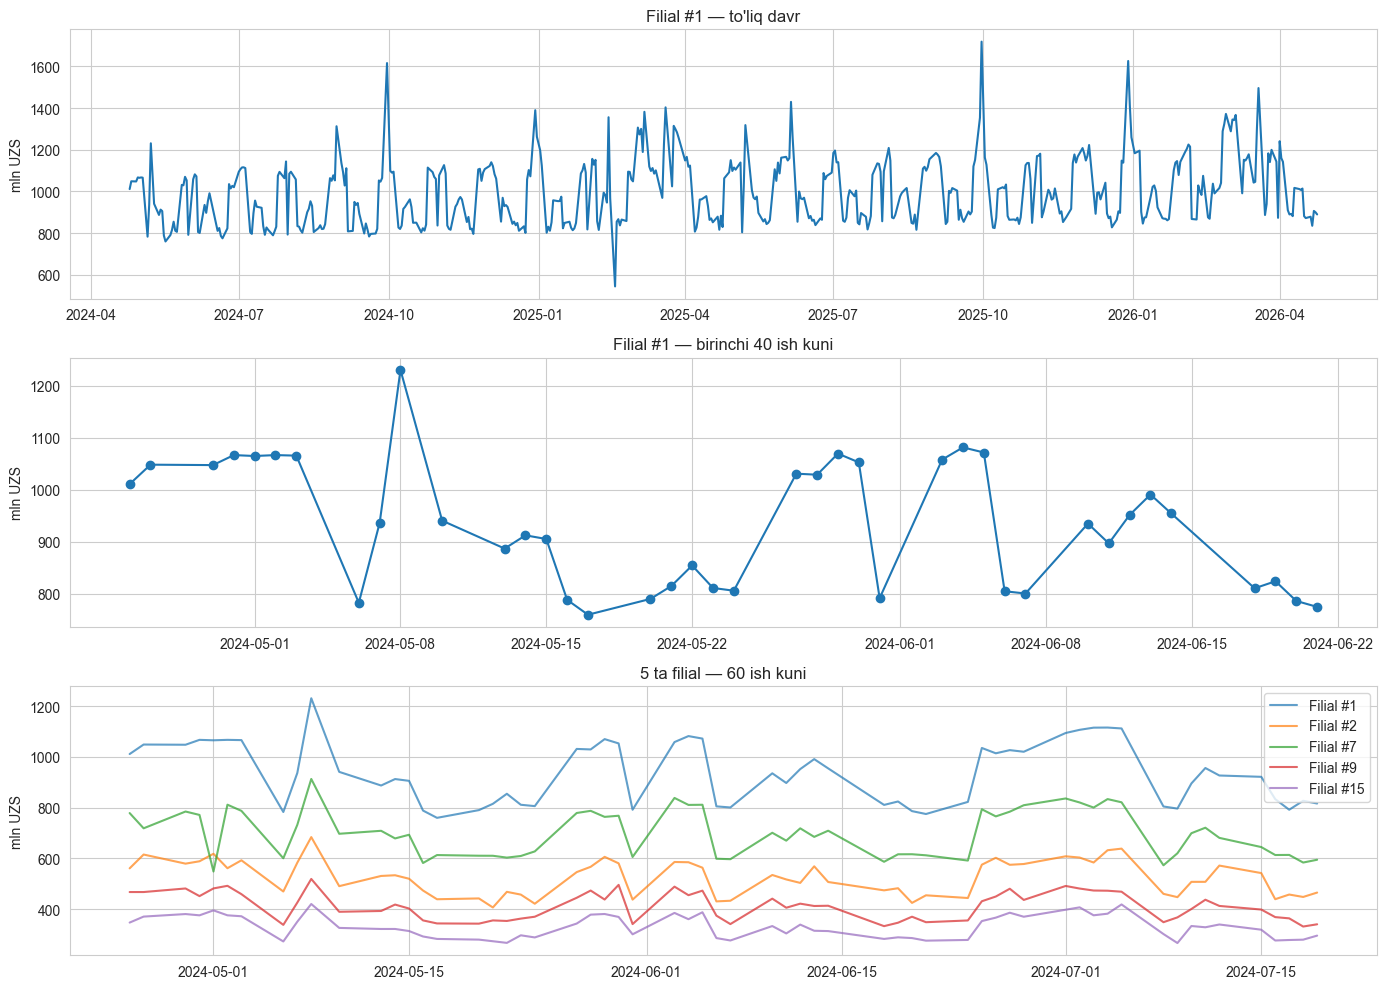

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

sample = data[data['branch_id'] == 1]
axes[0].plot(sample['date'], sample['balance'] / 1e6)
axes[0].set_title("Filial #1 — to'liq davr")
axes[0].set_ylabel('mln UZS')

sample_short = sample.head(40)
axes[1].plot(sample_short['date'], sample_short['balance'] / 1e6, marker='o')
axes[1].set_title('Filial #1 — birinchi 40 ish kuni')
axes[1].set_ylabel('mln UZS')

for bid in [1, 2, 7, 9, 15]:
    s = data[data['branch_id'] == bid].head(60)
    axes[2].plot(s['date'], s['balance'] / 1e6, label=f'Filial #{bid}', alpha=0.7)
axes[2].set_title('5 ta filial — 60 ish kuni')
axes[2].set_ylabel('mln UZS')
axes[2].legend()

plt.tight_layout()
plt.show()